# Deep Learning Grokking Phenomenon

This notebook demonstrates **grokking** - a fascinating phenomenon where neural networks suddenly transition from memorization to generalization after prolonged training, even after training loss has reached near-zero.

## What is Grokking?

Discovered by Power et al. (2022), grokking describes an unexpected behavior in neural network training:

1. **Initial phase**: Model quickly overfits training data (100% train accuracy, poor test accuracy)
2. **Plateau phase**: Both metrics remain static for thousands of steps
3. **Grokking phase**: Test accuracy suddenly jumps to near-perfect, sometimes after 10,000+ steps

This challenges the conventional wisdom that generalization happens early in training. The phenomenon is most reliably observed in:
- Algorithmic tasks (modular arithmetic, permutation groups)
- Small datasets (model can memorize all examples)
- Strong regularization (weight decay is crucial)

## Setup

We'll import the necessary libraries and set our random seed for reproducibility.

In [ ]:

set_seed(42)
device = get_device()
print(f"Using device: {device}")

## The Task: Modular Addition

We'll use **modular addition**: given two numbers $a$ and $b$, predict $(a + b) \mod p$.

For $p = 97$, this creates $97^2 = 9,409$ possible inputs. This is small enough to memorize, but the underlying pattern requires true understanding of modular arithmetic.

### Generate All Possible Examples

We create every possible pair $(a, b)$ where $a, b \in [0, p-1]$.

In [2]:
p = 97  # Prime modulus

# Generate all combinations
all_data = []
for a in range(p):
    for b in range(p):
        result = (a + b) % p
        all_data.append((a, b, result))

all_data = np.array(all_data)
print(f"Total examples: {len(all_data)}")
print(f"Example: 43 + 67 ≡ {(43 + 67) % p} (mod {p})")

Total examples: 9409
Example: 43 + 67 ≡ 13 (mod 97)


### Train/Validation Split

We'll use only 30% for training and 70% for validation. This small training set forces the model to generalize - it can't rely on memorization alone.

In [3]:
# Shuffle and split (30% train, 70% val)
np.random.shuffle(all_data)
split_idx = int(len(all_data) * 0.3)

train_data = all_data[:split_idx]
val_data = all_data[split_idx:]

print(f"Train examples: {len(train_data)} ({len(train_data)/len(all_data)*100:.0f}%)")
print(f"Val examples: {len(val_data)} ({len(val_data)/len(all_data)*100:.0f}%)")

Train examples: 2822 (30%)
Val examples: 6587 (70%)


### Dataset Class

PyTorch Dataset that returns input pairs and their modular sum.

In [ ]:
from torch.utils.data import Dataset, DataLoader

In [4]:
class ModularArithmeticDataset(Dataset):
    def __init__(self, data):
        self.data = data
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        a, b, result = self.data[idx]
        # Return as long tensors for embedding/classification
        return torch.tensor([a, b], dtype=torch.long), torch.tensor(result, dtype=torch.long)

### Create DataLoaders

Small batch size helps observe grokking more clearly.

In [5]:
train_dataset = ModularArithmeticDataset(train_data)
val_dataset = ModularArithmeticDataset(val_data)

batch_size = 512
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

print(f"Batches per epoch: {len(train_loader)}")

Batches per epoch: 6


## Model Architecture

We use a simple architecture:
1. **Embedding layer**: Maps each input number to a learned vector
2. **MLP layers**: Process the concatenated embeddings
3. **Output layer**: Predicts one of $p$ possible results

This is deliberately simple - grokking emerges from the learning dynamics, not architectural complexity.

In [6]:
class ModularAdditionModel(nn.Module):
    def __init__(self, p, embedding_dim=128, hidden_dim=512):
        super().__init__()
        self.p = p
        
        # Embed each input number
        self.embedding = nn.Embedding(p, embedding_dim)
        
        # MLP layers
        self.mlp = nn.Sequential(
            nn.Linear(2 * embedding_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, p)
        )
    
    def forward(self, x):
        # x shape: (batch, 2) containing [a, b]
        a_emb = self.embedding(x[:, 0])  # (batch, embedding_dim)
        b_emb = self.embedding(x[:, 1])  # (batch, embedding_dim)
        
        # Concatenate and pass through MLP
        combined = torch.cat([a_emb, b_emb], dim=1)  # (batch, 2*embedding_dim)
        logits = self.mlp(combined)  # (batch, p)
        
        return logits

### Initialize Model

Create the model and move it to the appropriate device.

In [7]:
model = ModularAdditionModel(p).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")
print(f"\nModel architecture:")
print(model)

Total parameters: 456,417

Model architecture:
ModularAdditionModel(
  (embedding): Embedding(97, 128)
  (mlp): Sequential(
    (0): Linear(in_features=256, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=97, bias=True)
  )
)


## Training Setup

**Critical for grokking**: We use AdamW with weight decay ($\lambda = 0.5$). Weight decay is essential - without it, grokking rarely occurs. The moderate value delays grokking, making the phenomenon more dramatic.

In [8]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.5)

print("Optimizer configured:")
print(f"  Learning rate: {optimizer.param_groups[0]['lr']}")
print(f"  Weight decay: {optimizer.param_groups[0]['weight_decay']}")

Optimizer configured:
  Learning rate: 0.001
  Weight decay: 0.5


## Evaluation Function

Compute accuracy on a given dataset. We track accuracy rather than loss to clearly see the generalization jump.

In [9]:
def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            predictions = outputs.argmax(dim=1)
            correct += (predictions == targets).sum().item()
            total += targets.size(0)
    
    return correct / total

## Training Loop

We'll train for many steps to observe grokking. With our harder setup (30% training data), the phenomenon may take 5,000-10,000+ steps.

Watch for:
1. Train accuracy quickly reaching ~100%
2. Val accuracy staying low for thousands of steps
3. Sudden jump in val accuracy (the "grok" moment)

In [ ]:
from tqdm.auto import tqdm

In [10]:
num_epochs = 10000
eval_interval = 100  # Evaluate every N epochs

# Tracking metrics
history = {
    'epoch': [],
    'train_acc': [],
    'val_acc': [],
    'train_loss': []
}

print("Starting training...")
pbar = tqdm(range(num_epochs), desc="Training")

for epoch in pbar:
    model.train()
    epoch_loss = 0
    
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
    
    # Evaluate periodically
    if epoch % eval_interval == 0 or epoch == num_epochs - 1:
        train_acc = evaluate(model, train_loader)
        val_acc = evaluate(model, val_loader)
        avg_loss = epoch_loss / len(train_loader)
        
        history['epoch'].append(epoch)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['train_loss'].append(avg_loss)
        
        pbar.set_postfix({
            'train_acc': f'{train_acc:.3f}',
            'val_acc': f'{val_acc:.3f}',
            'loss': f'{avg_loss:.4f}'
        })

print("\nTraining complete!")

Starting training...


Training:   0%|          | 0/10000 [00:00<?, ?it/s]


Training complete!


## Visualizing Grokking

Plot train and validation accuracy over time. The grokking phenomenon appears as a delayed, sudden jump in validation accuracy.

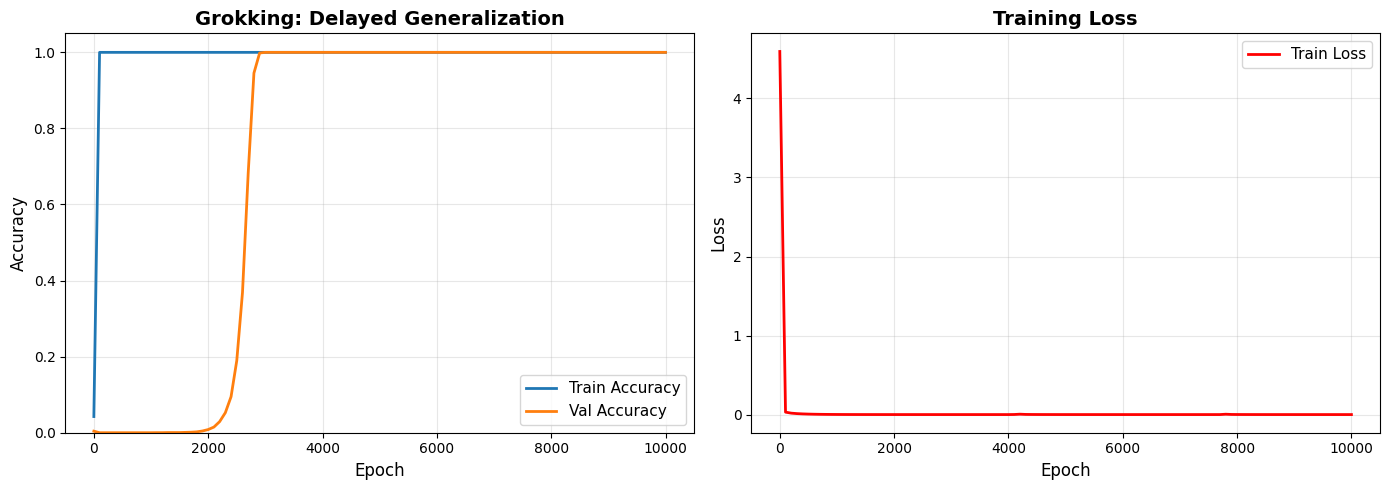


Final Results:
  Train Accuracy: 1.0000
  Val Accuracy: 1.0000


In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
ax1.plot(history['epoch'], history['train_acc'], label='Train Accuracy', linewidth=2)
ax1.plot(history['epoch'], history['val_acc'], label='Val Accuracy', linewidth=2)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.set_title('Grokking: Delayed Generalization', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.set_ylim([0, 1.05])

# Loss plot
ax2.plot(history['epoch'], history['train_loss'], label='Train Loss', linewidth=2, color='red')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Loss', fontsize=12)
ax2.set_title('Training Loss', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print final metrics
print(f"\nFinal Results:")
print(f"  Train Accuracy: {history['train_acc'][-1]:.4f}")
print(f"  Val Accuracy: {history['val_acc'][-1]:.4f}")

## Finding the Grok Point

Identify when validation accuracy crosses a threshold (e.g., 99%), marking the approximate "grok moment".

In [12]:
threshold = 0.99
grok_epochs = [e for e, acc in zip(history['epoch'], history['val_acc']) if acc >= threshold]

if grok_epochs:
    grok_epoch = grok_epochs[0]
    print(f"🎯 Grokking occurred around epoch {grok_epoch}!")
    print(f"   (Val accuracy first exceeded {threshold*100:.0f}%)")
    
    # Find corresponding train accuracy at that point
    idx = history['epoch'].index(grok_epoch)
    train_at_grok = history['train_acc'][idx]
    print(f"\n   Train accuracy at grok point: {train_at_grok:.4f}")
    print(f"   Train accuracy reached near-perfect early, but generalization took {grok_epoch} epochs!")
else:
    print(f"⚠️ Grokking not yet observed (val acc < {threshold*100:.0f}%)")
    print(f"   Consider training for more epochs or adjusting weight decay.")

🎯 Grokking occurred around epoch 2900!
   (Val accuracy first exceeded 99%)

   Train accuracy at grok point: 1.0000
   Train accuracy reached near-perfect early, but generalization took 2900 epochs!


## Test the Model

Verify the model has truly learned modular arithmetic by testing on specific examples.

In [13]:
def test_prediction(a, b):
    model.eval()
    with torch.no_grad():
        inputs = torch.tensor([[a, b]], dtype=torch.long).to(device)
        outputs = model(inputs)
        prediction = outputs.argmax(dim=1).item()
    
    true_answer = (a + b) % p
    correct = "✓" if prediction == true_answer else "✗"
    print(f"{a} + {b} ≡ {prediction} (mod {p})  [True: {true_answer}] {correct}")

# Test several random examples
print("Sample predictions:\n")
test_cases = [(23, 45), (89, 67), (12, 85), (96, 96), (0, 0)]
for a, b in test_cases:
    test_prediction(a, b)

Sample predictions:

23 + 45 ≡ 68 (mod 97)  [True: 68] ✓
89 + 67 ≡ 59 (mod 97)  [True: 59] ✓
12 + 85 ≡ 0 (mod 97)  [True: 0] ✓
96 + 96 ≡ 95 (mod 97)  [True: 95] ✓
0 + 0 ≡ 0 (mod 97)  [True: 0] ✓


## Why Does Grokking Happen?

Several theories attempt to explain grokking:

### 1. **Circuit Efficiency Hypothesis**
- Early: Model learns complex, memorization-based "circuits"
- Weight decay penalizes complexity
- Later: Model discovers simpler, generalizing circuits that are both accurate and lower-norm

### 2. **Regularization Dynamics**
- Strong weight decay continues to reshape the solution even after training loss plateaus
- Eventually finds a minimum that's both accurate and simpler (better generalization)

### 3. **Representation Learning**
- Model gradually learns structured representations (e.g., cyclic group structure for modular arithmetic)
- These representations emerge slowly but generalize perfectly once formed

The phenomenon highlights that:
- **Generalization can happen very late in training**
- **Regularization is crucial** (weight decay, dropout, etc.)
- **Training metrics can be misleading** (low train loss ≠ good generalization)

## Experiments to Try

Modify the notebook to explore how different factors affect grokking:

1. **Weight Decay**: Try `weight_decay=0.0` - does grokking still occur?
2. **Model Size**: Increase/decrease `hidden_dim` - how does capacity affect grokking timing?
3. **Learning Rate**: Try `lr=1e-4` or `lr=1e-2` - faster or slower grokking?
4. **Data Split**: Use 80/20 or 30/70 train/val - does more training data help?
5. **Different Operations**: Try multiplication (`(a * b) % p`) or subtraction
6. **Larger Modulus**: Use `p=113` - more data, longer to grok?

Each experiment reveals something about the underlying dynamics of neural network learning!

## Summary

We've demonstrated **grokking** - the surprising phenomenon where:

1. ✅ Model quickly memorizes training data (high train accuracy)
2. ⏸️ Validation accuracy remains poor for thousands of steps
3. 🚀 Sudden transition to near-perfect generalization

Key insights:
- **Regularization matters**: Weight decay is essential for grokking
- **Patience pays off**: Don't stop training just because train loss plateaued
- **Algorithmic tasks**: Clear, learnable patterns make grokking more observable
- **Generalization is complex**: The path from memorization to understanding can be long and nonlinear

Grokking challenges our intuitions about how and when neural networks learn to generalize!